In [1]:
import os
import random
import numpy as np
import torch

def set_seed(seed=42):
    random.seed(seed)

    np.random.seed(seed)

    torch.manual_seed(seed)

    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    os.environ["PYTHONHASHSEED"] = str(seed)

set_seed(42)

In [2]:
import requests

url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
text = requests.get(url).text

print("length:", len(text))

from collections import defaultdict, Counter

def get_vocab(text):
    vocab = Counter()
    for word in text.split():
        chars = tuple(word) + ("</w>",)
        vocab[chars] += 1
    return vocab

length: 1115394


In [ ]:
import re
import math
from collections import Counter, defaultdict

def pretokenize(text):
    return re.findall(r"\w+|[^\w\s]", text.lower())

def get_vocab(text_tokens):
    vocab = Counter()
    for token in text_tokens:
        chars = tuple(token) + ("</w>",)
        vocab[chars] += 1
    return vocab


def get_base_vocab(text_tokens):
    base_vocab = set()
    for token in text_tokens:
        for ch in token:
            base_vocab.add(ch)
    base_vocab.update(["</w>", "<unk>"])
    return base_vocab

def get_stats(vocab):
    pairs = Counter()
    for word, freq in vocab.items():
        for i in range(len(word) - 1):
            pairs[(word[i], word[i+1])] += freq
    return pairs

def merge_vocab(pair, vocab):
    new_vocab = {}

    for word, freq in vocab.items():
        new_word = []
        i = 0

        while i < len(word):
            if i < len(word) - 1 and (word[i], word[i+1]) == pair:
                new_word.append(word[i] + word[i+1])
                i += 2
            else:
                new_word.append(word[i])
                i += 1

        new_vocab[tuple(new_word)] = freq

    return new_vocab

def train_bpe(text_tokens, max_vocab_size=500):

    vocab = get_vocab(text_tokens)
    base_vocab = get_base_vocab(text_tokens)

    merges = []
    target_merges = max_vocab_size - len(base_vocab)

    print("base vocab:", len(base_vocab))
    print("target merges:", target_merges)

    for _ in range(target_merges):
        pairs = get_stats(vocab)
        if not pairs:
            break

        best = max(pairs, key=pairs.get)
        if pairs[best] < 2:
            break

        vocab = merge_vocab(best, vocab)
        merges.append(best)

    return merges, base_vocab

def encode_word(word, merges):
    tokens = list(word) + ["</w>"]

    for pair in merges:
        i = 0
        new_tokens = []

        while i < len(tokens):
            if i < len(tokens)-1 and (tokens[i], tokens[i+1]) == pair:
                new_tokens.append(tokens[i] + tokens[i+1])
                i += 2
            else:
                new_tokens.append(tokens[i])
                i += 1

        tokens = new_tokens

    return tokens

def encode(text_tokens, merges):
    tokens = []
    for word in text_tokens:
        tokens.extend(encode_word(word, merges))
    return tokens

def build_vocab(base_vocab, merges):
    vocab = set(base_vocab)
    for pair in merges:
        vocab.add("".join(pair))
    return sorted(vocab)

text_tokens = pretokenize(text)

merges, base_vocab = train_bpe(text_tokens, max_vocab_size=500)

full_vocab = build_vocab(base_vocab, merges)

stoi = {tok: i for i, tok in enumerate(full_vocab)}
itos = {i: tok for tok, i in stoi.items()}

tokens = encode(text_tokens, merges)

ids = [stoi.get(t, stoi["<unk>"]) for t in tokens]

print("vocab size:", len(full_vocab))
print("max id:", max(ids))
assert max(ids) < len(full_vocab)

base vocab: 39
target merges: 461
vocab size: 500
max id: 499


In [4]:
def create_sequences(token_ids, seq_len=50, stride=25):
    inputs = []
    targets = []

    for i in range(0, len(token_ids) - seq_len, stride):
        x = token_ids[i:i+seq_len]
        y = token_ids[i+1:i+seq_len+1]

        inputs.append(x)
        targets.append(y)

    return inputs, targets

In [5]:

import torch
from torch.utils.data import Dataset

class ShakespeareDataset(Dataset):
    def __init__(self, token_ids, seq_len=50):
        self.inputs, self.targets = create_sequences(token_ids, seq_len)

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.inputs[idx], dtype=torch.long),
            torch.tensor(self.targets[idx], dtype=torch.long),
        )


from torch.utils.data import DataLoader


In [69]:
import numpy as np

seq_len = 50
batch_size = 16

ids = np.array(ids)

split_idx = int(len(ids) * 0.8)

train_ids = ids[:split_idx]
val_ids = ids[split_idx:]

print("train tokens:", len(train_ids))
print("val tokens:", len(val_ids))


train_dataset = ShakespeareDataset(train_ids, seq_len)
val_dataset = ShakespeareDataset(val_ids, seq_len)

from torch.utils.data import DataLoader

g = torch.Generator()
g.manual_seed(42)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    generator=g
)

val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print("train samples:", len(train_dataset))
print("val samples:", len(val_dataset))

import torch.nn as nn

vocab_size = len(full_vocab)
d_model = 64  

token_embedding = nn.Embedding(vocab_size, d_model)

train tokens: 347377
val tokens: 86845
train samples: 13894
val samples: 3472


In [ ]:
import torch
import math
import torch.nn as nn


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.pe = pe.unsqueeze(0) 

    def forward(self, x):
        seq_len = x.size(1)
        return x + self.pe[:, :seq_len].to(x.device)

# class InputEmbedding(nn.Module):
#     def __init__(self, vocab_size, d_model):
#         super().__init__()
#         self.token_emb = nn.Embedding(vocab_size, d_model)
#         self.pos_enc = PositionalEncoding(d_model)

#     def forward(self, x):
#         x = self.token_emb(x)         
#         x = self.pos_enc(x)            
#         return x

class InputEmbedding(nn.Module):
    def __init__(self, vocab_size, d_model):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, d_model)

    def forward(self, x):
        x = self.token_emb(x)
        return x

device = "cuda" if torch.cuda.is_available() else "cpu"

model_input = InputEmbedding(vocab_size, d_model).to(device)

for x, y in train_loader:
    x = x.to(device)
    out = model_input(x)

    print("input shape:", x.shape)      
    print("embedding shape:", out.shape)  
    break

input shape: torch.Size([16, 50])
embedding shape: torch.Size([16, 50, 64])


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()

        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1)

        div = torch.exp(
            torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)

        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


class SelfAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0

        self.num_heads = num_heads
        self.head_dim = d_model // num_heads

        self.qkv = nn.Linear(d_model, 3 * d_model)
        self.proj = nn.Linear(d_model, d_model)

    def forward(self, x, return_attn=False):
        B, T, C = x.shape

        qkv = self.qkv(x)
        q, k, v = qkv.chunk(3, dim=-1)

        q = q.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)

        attn = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)

        mask = torch.tril(torch.ones(T, T, device=x.device))
        attn = attn.masked_fill(mask == 0, float("-inf"))

        attn = F.softmax(attn, dim=-1)

        out = attn @ v
        out = out.transpose(1, 2).contiguous().view(B, T, C)
        out = self.proj(out)

        if return_attn:
            return out, attn.detach()
        return out


class FeedForward(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, 4 * d_model),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(4 * d_model, d_model),
        )

    def forward(self, x):
        return self.net(x)

class TransformerBlock(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()

        self.norm1 = nn.LayerNorm(d_model)
        self.attn = SelfAttention(d_model, num_heads)
        self.norm2 = nn.LayerNorm(d_model)
        self.ffn = FeedForward(d_model)

    def forward(self, x, return_attn=False):

        if return_attn:
            attn_out, attn = self.attn(self.norm1(x), return_attn=True)
            x = x + attn_out
            x = x + self.ffn(self.norm2(x))
            return x, attn
        else:
            x = x + self.attn(self.norm1(x))
            x = x + self.ffn(self.norm2(x))
            return x


class TinyTransformer(nn.Module):
    def __init__(self, vocab_size, d_model=128, num_layers=2, num_heads=4):
        super().__init__()

        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.pos_enc = PositionalEncoding(d_model)

        self.blocks = nn.ModuleList([
            TransformerBlock(d_model, num_heads)
            for _ in range(num_layers)
        ])

        self.norm = nn.LayerNorm(d_model)

        self.lm_head = nn.Linear(d_model, vocab_size)

    def forward(self, x, return_attn=False):

        x = self.token_emb(x)
        x = self.pos_enc(x)

        attn_maps = []

        for block in self.blocks:
            if return_attn:
                x, attn = block(x, return_attn=True)
                attn_maps.append(attn)
            else:
                x = block(x)

        x = self.norm(x)
        logits = self.lm_head(x)

        if return_attn:
            return logits, attn_maps
        return logits

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

lr=3e-3
decay=0.01
model = TinyTransformer(vocab_size).to(device)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=lr,
    weight_decay=decay
)

def train_epoch(loader):
    model.train()
    total_loss = 0
    total_tokens = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        logits = model(x)

        loss = F.cross_entropy(
            logits.view(-1, vocab_size),
            y.view(-1),
            reduction='sum'   
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_tokens += y.numel()

    return total_loss / total_tokens

@torch.no_grad()
def evaluate(loader):
    model.eval()
    total_loss = 0
    total_tokens = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        logits = model(x)

        loss = F.cross_entropy(
            logits.view(-1, vocab_size),
            y.view(-1),
            reduction='sum'
        )

        total_loss += loss.item()
        total_tokens += y.numel()

    return total_loss / total_tokens

In [ ]:
import copy
import torch

epochs = 10
# epochs = 20

train_losses = []
val_losses = []

best_val_loss = float('inf')
best_model_state = None

save_epochs = {1, 5, 10}

for epoch in range(epochs):
    train_loss = train_epoch(train_loader)
    val_loss = evaluate(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1} | train: {train_loss:.4f} | val: {val_loss:.4f}")

    if (epoch + 1) in save_epochs:
        torch.save(
            model.state_dict(),
            f"model_epoch_{epoch+1}.pt"
        )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = copy.deepcopy(model.state_dict())
        torch.save(best_model_state, "model_best.pt")

Epoch 1 | train: 4.0252 | val: 4.0873
Epoch 2 | train: 3.4788 | val: 3.9308
Epoch 3 | train: 3.2965 | val: 3.8973
Epoch 4 | train: 3.1835 | val: 3.8746
Epoch 5 | train: 3.1009 | val: 3.8880
Epoch 6 | train: 3.0344 | val: 3.9255
Epoch 7 | train: 2.9775 | val: 3.9476
Epoch 8 | train: 2.9272 | val: 3.9752
Epoch 9 | train: 2.8839 | val: 3.9905
Epoch 10 | train: 2.8456 | val: 4.0195


seq_len: 80
d_model: 64


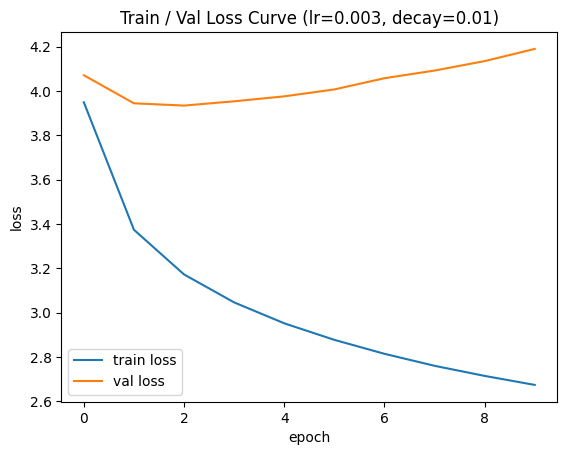

In [65]:
import matplotlib.pyplot as plt

print('seq_len:', seq_len)
print('d_model:', d_model)

plt.plot(train_losses, label="train loss")
plt.plot(val_losses, label="val loss")

plt.xlabel("epoch")
plt.ylabel("loss")
plt.title(f"Train / Val Loss Curve (lr={lr}, decay={decay})")
plt.legend()
plt.show()

seq_len: 50
d_model: 64


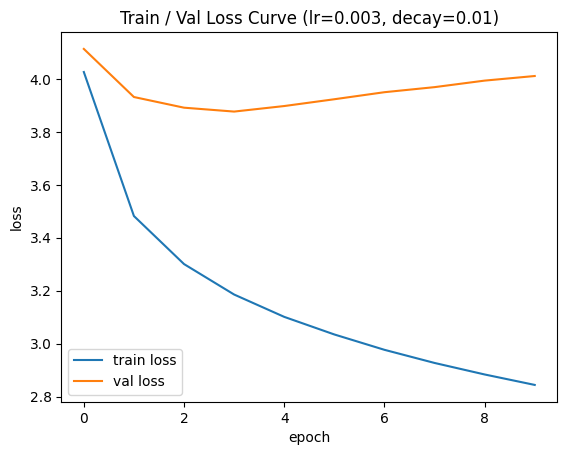

In [57]:
import matplotlib.pyplot as plt

print('seq_len:', seq_len)
print('d_model:', d_model)

plt.plot(train_losses, label="train loss")
plt.plot(val_losses, label="val loss")

plt.xlabel("epoch")
plt.ylabel("loss")
plt.title(f"Train / Val Loss Curve (lr={lr}, decay={decay})")
plt.legend()
plt.show()

seq_len: 80


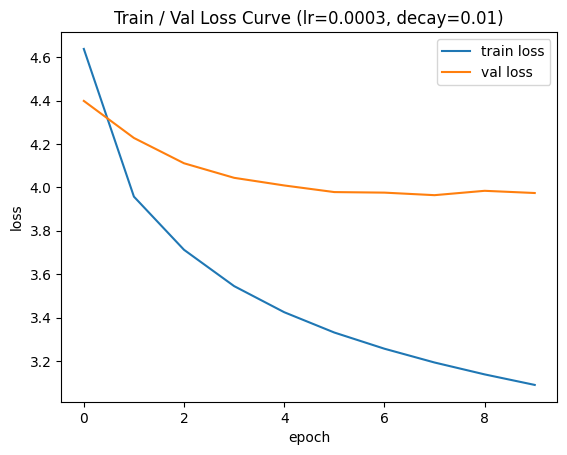

In [30]:
import matplotlib.pyplot as plt

print('seq_len:', seq_len)
plt.plot(train_losses, label="train loss")
plt.plot(val_losses, label="val loss")

plt.xlabel("epoch")
plt.ylabel("loss")
plt.title(f"Train / Val Loss Curve (lr={lr}, decay={decay})")
plt.legend()
plt.show()

seq_len: 80


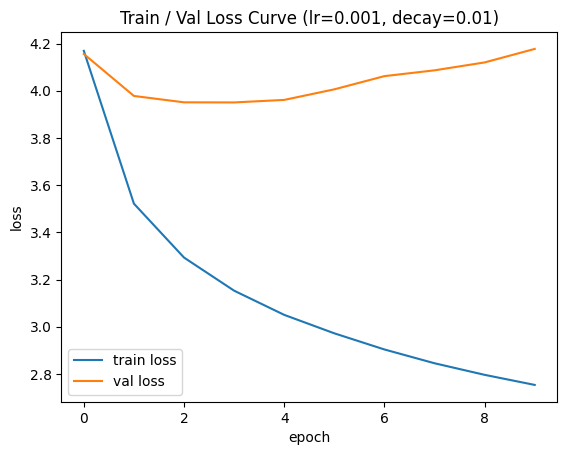

In [25]:
import matplotlib.pyplot as plt

print('seq_len:', seq_len)
plt.plot(train_losses, label="train loss")
plt.plot(val_losses, label="val loss")

plt.xlabel("epoch")
plt.ylabel("loss")
plt.title(f"Train / Val Loss Curve (lr={lr}, decay={decay})")
plt.legend()
plt.show()

seq_len: 80


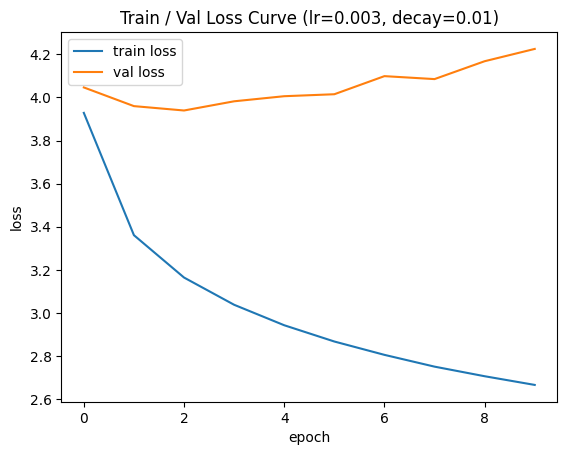

In [19]:
import matplotlib.pyplot as plt

print('seq_len:', seq_len)
plt.plot(train_losses, label="train loss")
plt.plot(val_losses, label="val loss")

plt.xlabel("epoch")
plt.ylabel("loss")
plt.title(f"Train / Val Loss Curve (lr={lr}, decay={decay})")
plt.legend()
plt.show()

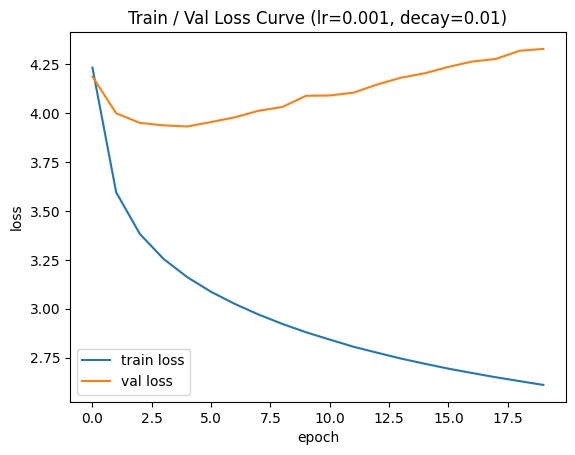

In [26]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label="train loss")
plt.plot(val_losses, label="val loss")

plt.xlabel("epoch")
plt.ylabel("loss")
plt.title(f"Train / Val Loss Curve (lr={lr}, decay={decay})")
plt.legend()
plt.show()

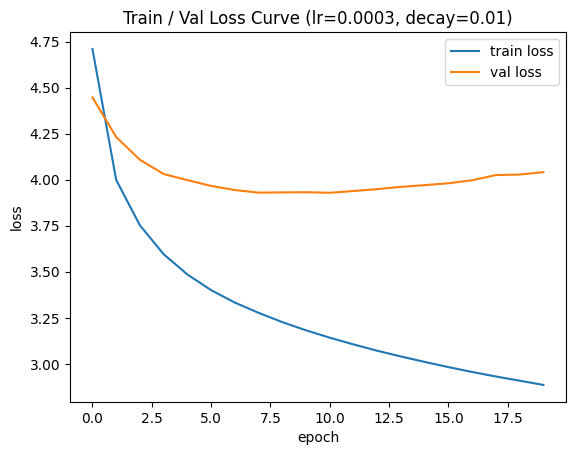

In [12]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label="train loss")
plt.plot(val_losses, label="val loss")

plt.xlabel("epoch")
plt.ylabel("loss")
plt.title(f"Train / Val Loss Curve (lr={lr}, decay={decay})")
plt.legend()
plt.show()

In [19]:
for i in range(10,15):
    x, y = val_dataset[i]

    tokens = [itos[idx.item()] for idx in x]
    target_tokens = [itos[idx.item()] for idx in y]

    print(f"\n--- sample {i} ---")
    print("input tokens : ", tokens)
    print("target tokens: ", target_tokens)


--- sample 10 ---
input tokens :  ['ne', 'y</w>', ',</w>', 'and</w>', 'death</w>', 'un', 'lo', 'a', 'ds</w>', 'thee</w>', '.</w>', 'fri', 'end</w>', 'ha', 'st</w>', 'thou</w>', 'no', 'ne</w>', ';</w>', 'for</w>', 'th', 'ine</w>', 'o', 'wn</w>', 'bo', 'w', 'el', 's</w>', ',</w>', 'which</w>', 'do</w>', 'ca', 'll</w>', 'thee</w>', 'si', 'r', 'e</w>', ',</w>', 'the</w>', 'm', 'ere</w>', 'e', 'f', 'fu', 'si', 'on</w>', 'of</w>', 'thy</w>', 'pro', 'p']
target tokens:  ['y</w>', ',</w>', 'and</w>', 'death</w>', 'un', 'lo', 'a', 'ds</w>', 'thee</w>', '.</w>', 'fri', 'end</w>', 'ha', 'st</w>', 'thou</w>', 'no', 'ne</w>', ';</w>', 'for</w>', 'th', 'ine</w>', 'o', 'wn</w>', 'bo', 'w', 'el', 's</w>', ',</w>', 'which</w>', 'do</w>', 'ca', 'll</w>', 'thee</w>', 'si', 'r', 'e</w>', ',</w>', 'the</w>', 'm', 'ere</w>', 'e', 'f', 'fu', 'si', 'on</w>', 'of</w>', 'thy</w>', 'pro', 'p', 'er</w>']

--- sample 11 ---
input tokens :  ['w', 'el', 's</w>', ',</w>', 'which</w>', 'do</w>', 'ca', 'll</w>', 'thee

In [81]:
model.load_state_dict(best_model_state)
print("Loaded best model with val loss:", best_val_loss)

Loaded best model with val loss: 3.8745609476819016


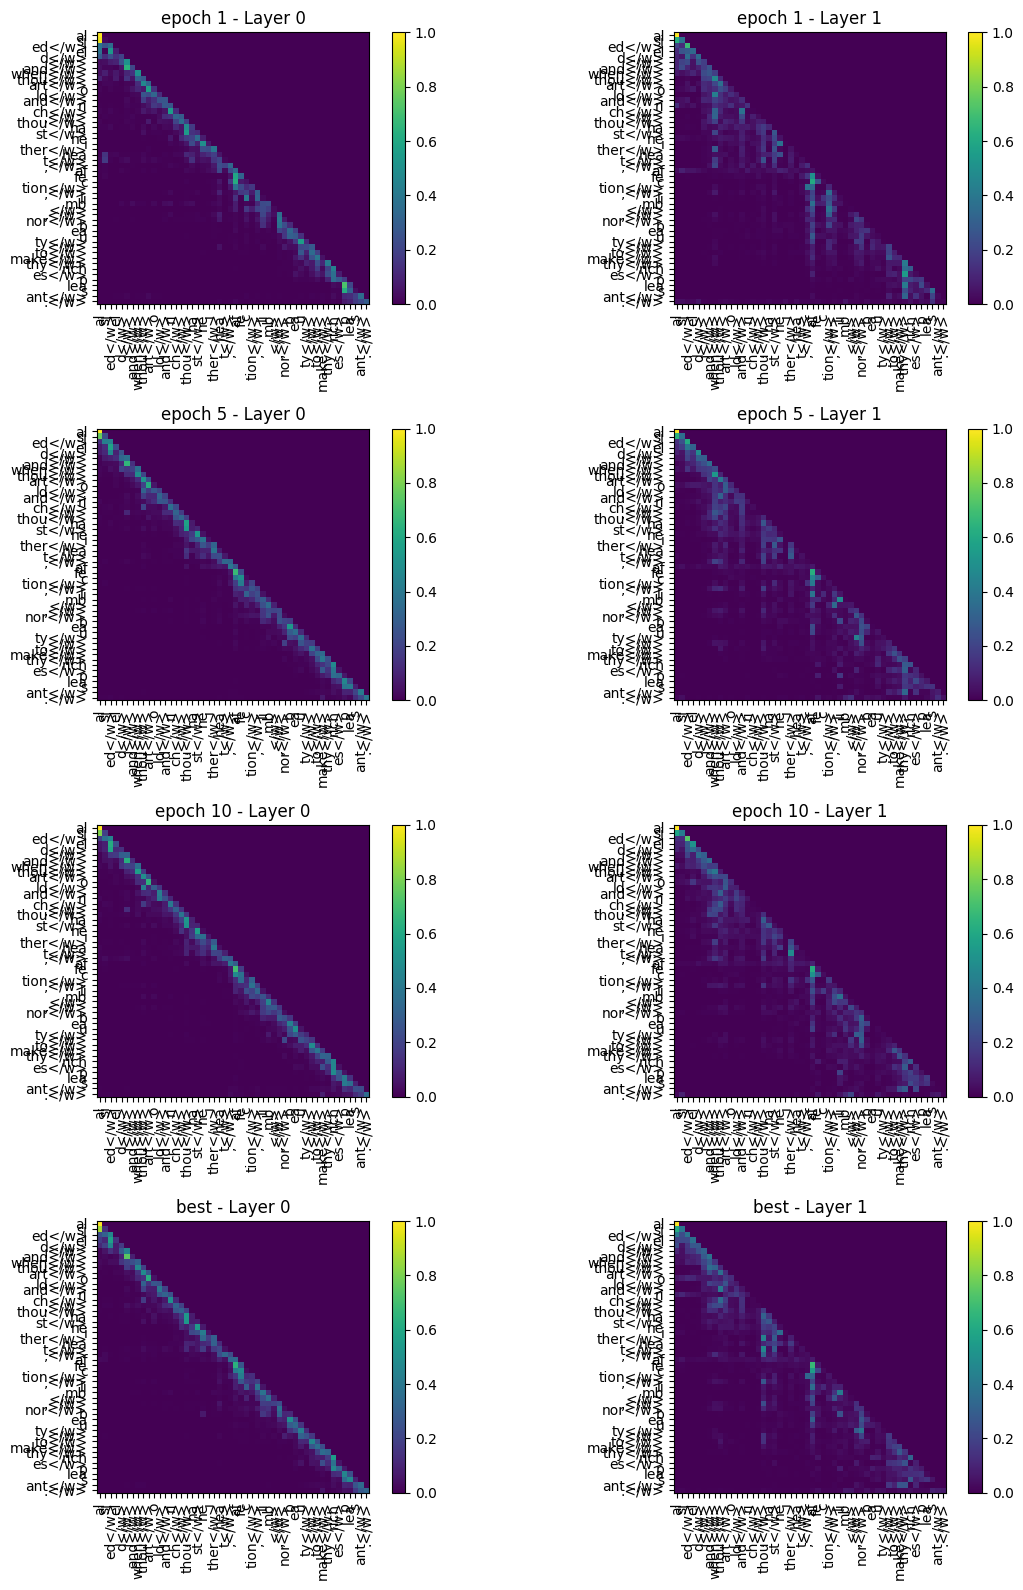

In [76]:
import matplotlib.pyplot as plt
import torch


def plot_attention_two_layers_from_checkpoint(
    model,
    checkpoint_paths,
    dataset,
    stoi,
    itos,
    device
):
    model.eval()

    x, y = dataset[14]
    x = x.unsqueeze(0).to(device)

    tokens = [itos[i.item()] for i in x[0]]

    num_models = len(checkpoint_paths)
    fig, axes = plt.subplots(num_models, 2, figsize=(12, 4 * num_models))

    if num_models == 1:
        axes = [axes]

    for idx, (tag, path) in enumerate(checkpoint_paths.items()):

        model.load_state_dict(torch.load(path, map_location=device))
        model.eval()

        with torch.no_grad():
            _, attn_maps = model(x, return_attn=True)

        layer0 = attn_maps[0][0].mean(0).detach().cpu().numpy()
        layer1 = attn_maps[1][0].mean(0).detach().cpu().numpy()

        ax0 = axes[idx][0]
        ax1 = axes[idx][1]

        im0 = ax0.imshow(layer0, cmap="viridis")
        ax0.set_title(f"{tag} - Layer 0")
        ax0.set_xticks(range(len(tokens)))
        ax0.set_yticks(range(len(tokens)))
        ax0.set_xticklabels(tokens, rotation=90)
        ax0.set_yticklabels(tokens)
        fig.colorbar(im0, ax=ax0, fraction=0.046, pad=0.04)

        im1 = ax1.imshow(layer1, cmap="viridis")
        ax1.set_title(f"{tag} - Layer 1")
        ax1.set_xticks(range(len(tokens)))
        ax1.set_yticks(range(len(tokens)))
        ax1.set_xticklabels(tokens, rotation=90)
        ax1.set_yticklabels(tokens)
        fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

checkpoint_paths = {
    "epoch 1": "model_epoch_1.pt",
    "epoch 5": "model_epoch_5.pt",
    "epoch 10": "model_epoch_10.pt",
    "best": "model_best.pt"
}

plot_attention_two_layers_from_checkpoint(
    model=model,
    checkpoint_paths=checkpoint_paths,
    dataset=val_dataset,
    stoi=stoi,
    itos=itos,
    device=device
)

In [82]:
import math
loss_fn = nn.CrossEntropyLoss(reduction='sum')
@torch.no_grad()
def compute_ppl(loader):
    model.eval()

    total_loss = 0.0
    total_tokens = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        # print('x:',x[0][:10])
        # print('y:',y[0][:10])

        logits = model(x)

        loss = loss_fn(
            logits.view(-1, vocab_size),
            y.view(-1)
        )

        total_loss += loss.item()
        total_tokens += y.numel()

    avg_loss = total_loss / total_tokens
    print("avg_loss:", avg_loss)
    ppl = math.exp(avg_loss)

    return ppl

In [83]:
val_ppl = compute_ppl(val_loader)
print(f"d_model={d_model}, seq_len={seq_len}, lr={lr}, decay={decay}, Validation Perplexity: {val_ppl}")



avg_loss: 3.8745609476819016
d_model=64, seq_len=50, lr=0.003, decay=0.01, Validation Perplexity: 48.1615482090579


In [59]:
val_ppl = compute_ppl(val_loader)
print(f"d_model={d_model}, seq_len={seq_len}, lr={lr}, decay={decay}, Validation Perplexity: {val_ppl}")



avg_loss: 3.8767166868992113
d_model=64, seq_len=50, lr=0.003, decay=0.01, Validation Perplexity: 48.26548393620913


In [51]:
val_ppl = compute_ppl(val_loader)
print(f"d_model={d_model}, seq_len={seq_len}, lr={lr}, decay={decay}, Validation Perplexity: {val_ppl}")



avg_loss: 3.9177843371374537
d_model=64, seq_len=80, lr=0.003, decay=0.01, Validation Perplexity: 50.28889800496963


In [44]:
val_ppl = compute_ppl(val_loader)
print(f"seq_len={seq_len}, lr={lr}, decay={decay}, Validation Perplexity: {val_ppl}")



avg_loss: 3.941047154555435
seq_len=80, lr=0.001, decay=0.01, Validation Perplexity: 51.47247272404348


In [40]:
val_ppl = compute_ppl(val_loader)
print(f"seq_len={seq_len}, lr={lr}, decay={decay}, Validation Perplexity: {val_ppl}")



avg_loss: 3.914865225723517
seq_len=80, lr=0.003, decay=0.01, Validation Perplexity: 50.142313161643685


In [34]:
val_ppl = compute_ppl(val_loader)
print(f"seq_len={seq_len}, lr={lr}, decay={decay}, Validation Perplexity: {val_ppl}")



avg_loss: 3.964230664955783
seq_len=80, lr=0.0003, decay=0.01, Validation Perplexity: 52.67972543680692


In [30]:
val_ppl = compute_ppl(val_loader)
print(f"lr={lr}, decay={decay}, Validation Perplexity: {val_ppl}")



avg_loss: 3.931585488033734
lr=0.001, decay=0.01, Validation Perplexity: 50.987754091233654


In [ ]:

val_ppl = compute_ppl(val_loader)
print(f"lr={lr}, decay={decay}, Validation Perplexity: {val_ppl}")



avg_loss: 3.923187267110095
lr=0.003, decay=0.01, Validation Perplexity: 50.56134073102287


In [ ]:


val_ppl = compute_ppl(val_loader)
print(f"lr={lr}, decay={decay}, Validation Perplexity: {val_ppl}")



avg_loss: 3.9406898210235455
lr=0.0003, decay=0.01, Validation Perplexity: 51.45408316936785
